In [21]:
# Data Analysis and Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
train_df=pd.read_csv('../dataset/diabetes_train.csv')
test_df=pd.read_csv('../dataset/diabetes_test.csv')

In [23]:
df=train_df.copy()

In [24]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,1,0,former,27.32,6.5,145,1
1,Female,19.0,0,0,never,25.18,4.5,126,0
2,Female,36.0,0,0,No Info,25.95,6.6,200,0
3,Female,35.0,0,0,current,23.43,6.0,159,0
4,Female,30.0,0,0,No Info,22.62,5.0,90,0


In [25]:
num_cols=df.select_dtypes(include=['int64','float64'])
cat_cols=df.select_dtypes(include=['str'])

In [26]:
correlation=num_cols.corr()
correlation

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251298,0.231535,0.338482,0.100839,0.107252,0.256102
hypertension,0.251298,1.000000,0.122558,0.145944,0.079488,0.084090,0.197955
heart_disease,0.231535,0.122558,1.000000,0.060758,0.066961,0.066395,0.169686
bmi,0.338482,0.145944,0.060758,1.000000,0.081959,0.084456,0.213176
HbA1c_level,0.100839,0.079488,0.066961,0.081959,1.000000,0.166340,0.400907
blood_glucose_level,0.107252,0.084090,0.066395,0.084456,0.166340,1.000000,0.417704
diabetes,0.256102,0.197955,0.169686,0.213176,0.400907,0.417704,1.000000


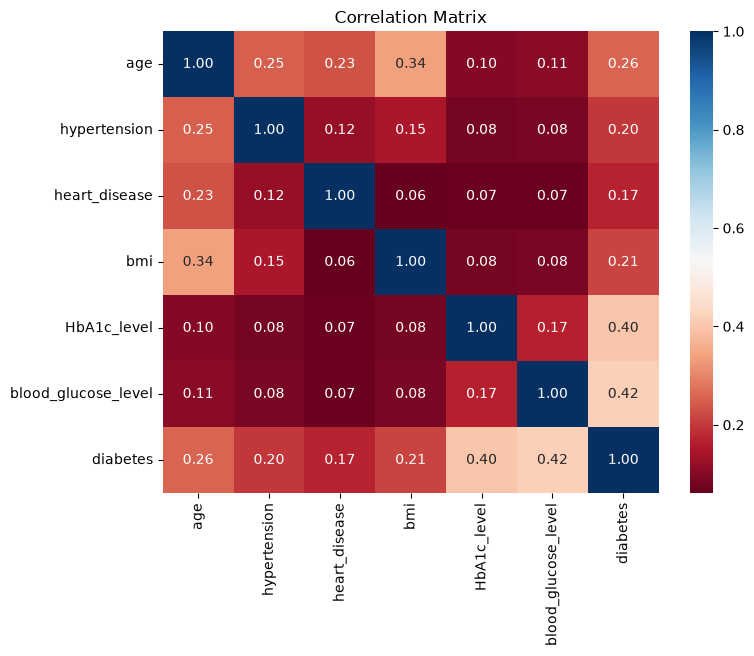

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap='RdBu',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

### Key Findings from the Correlation Matrix

#### 1. Positive Correlation Between Age and Medical Conditions

A weak positive correlation exists between age and hypertension (0.25), heart disease (0.23), and diabetes (0.26). These values suggest that increasing age is associated with a higher prevalence of these conditions in the dataset. However, the relatively weak correlations indicate that age alone does not fully explain the variation in these outcomes, and other variables may also contribute to their prediction.

#### 2. Relationships Involving BMI and HbA1c

Age and BMI exhibit a positive correlation of 0.34, indicating a modest linear association between the two variables. Additionally, HbA1c level has a positive correlation of 0.40 with diabetes. Since HbA1c reflects average blood glucose levels over approximately the preceding two to three months, this association is clinically relevant and makes HbA1c a potentially informative feature for diabetes prediction.

#### 3. Glucose Level Has the Strongest Observed Correlation with Diabetes

Among the relationships examined, glucose level has the highest positive correlation with diabetes (0.42). This is consistent with the clinical relationship between elevated blood glucose and diabetes. Consequently, glucose level is a promising candidate feature for the predictive model, alongside HbA1c, age, and other relevant variables.

### Conclusion

The correlation analysis identifies glucose level and HbA1c as promising features for diabetes prediction, while age and BMI may provide additional information. These observations will be investigated further during feature analysis and model evaluation. Correlation indicates association rather than causation, and the predictive importance of these features must ultimately be assessed using appropriate model evaluation techniques.




In [28]:
#Useful Count distributions for some features
print(f"{df['hypertension'].value_counts()}")
print('-'*27)
print(f"{df['heart_disease'].value_counts()}")
print('-'*27)
print(f"{df['gender'].value_counts()}")
print('-'*27)
print(f"{df['smoking_history'].value_counts()}")
print('-'*27)
print(f"{df['diabetes'].value_counts()}")
print('-'*27)

hypertension
0    74013
1     5987
Name: count, dtype: int64
---------------------------
heart_disease
0    76840
1     3160
Name: count, dtype: int64
---------------------------
gender
Female    46810
Male      33174
Other        16
Name: count, dtype: int64
---------------------------
smoking_history
No Info        28579
never          28082
former          7530
current         7443
not current     5182
ever            3184
Name: count, dtype: int64
---------------------------
diabetes
0    73200
1     6800
Name: count, dtype: int64
---------------------------


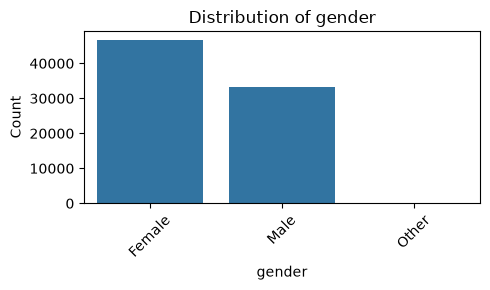

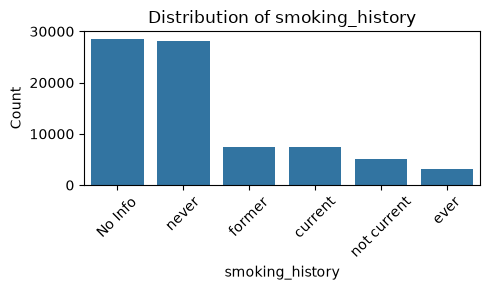

In [33]:
for col in cat_cols:
    plt.figure(figsize=(5, 3))

    counts = df[col].value_counts().reset_index()
    counts.columns = [col, "Count"]

    sns.barplot(data=counts, x=col, y="Count")

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

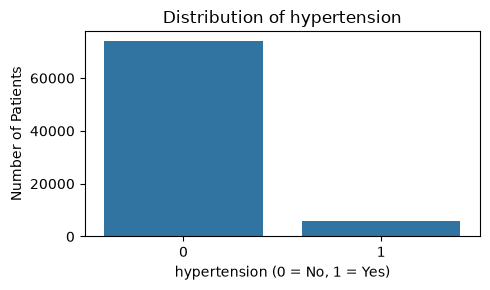

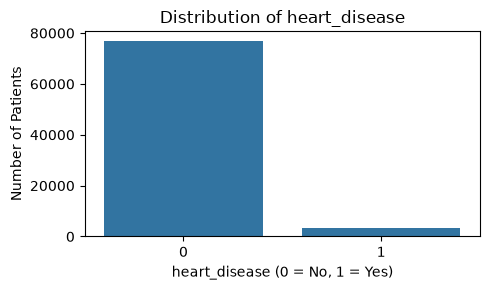

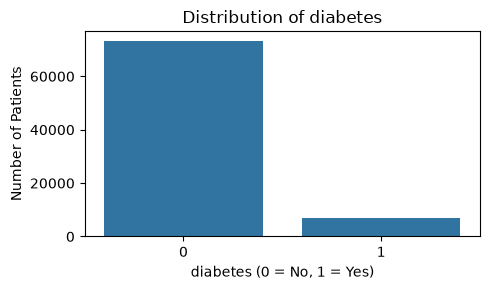

In [39]:
for col in ['hypertension', 'heart_disease', 'diabetes']:
    plt.figure(figsize=(5, 3))

    sns.countplot(data=df, x=col)

    plt.title(f"Distribution of {col}")
    plt.xlabel(f"{col} (0 = No, 1 = Yes)")
    plt.ylabel("Number of Patients")
    plt.tight_layout()
    plt.show()